In [98]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import re

First we will load all percipitation data before loading all the discharge data. This will then be saved into dataframes for further analysis.

In [99]:
percipitation_black = pd.read_csv(r"precipitation data volta\mswep\Black Volta_-2.75_9.55.csv", index_col=0, parse_dates=True)
percipitation_lake = pd.read_csv(r"precipitation data volta\mswep\Lake Volta_0.05_6.45.csv", index_col=0, parse_dates=True)
percipitation_mouhoun = pd.read_csv(r"precipitation data volta\mswep\Mouhoun_-3.95_12.05.csv", index_col=0, parse_dates=True)
percipitation_nakambe = pd.read_csv(r"precipitation data volta\mswep\Nakambe_-2.15_13.55.csv", index_col=0, parse_dates=True)
percipitation_oti = pd.read_csv(r"precipitation data volta\mswep\Oti_0.15_8.45.csv", index_col=0, parse_dates=True)
percipitation_pendjari = pd.read_csv(r"precipitation data volta\mswep\Pendjari_1.15_11.15.csv", index_col=0, parse_dates=True)


Discharge Data:

This data is loaded first to see what is going on. It is then split into the 2 rivers which it measures, and plotted against time. Data is taken 3 times per month. 

In [100]:
discharge = pd.read_excel(r"discharge data volta\discharge in columns.xlsx")
discharge.head()

,MOU HO,UN (VO,LTA NO,IRE),Unnamed: 4,Unnamed: 5,SA,MANDEN,I,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,2,2,2,2,2.0,2.0,2,2,2.0,2.0,NaN,1 11977
1,2,2,2,2,2.0,2.0,2,2,2.0,2.0,NaN,2 11977
2,2,2,2,2,2.0,2.0,2,2,2.0,2.0,2.0,3 11977
3,2,2,2,2,2.0,2.0,2,2,2.0,2.0,NaN,1 21977
4,2,2,2,2,2.0,2.0,2,2,2.0,2.0,NaN,2 21977


In [101]:

path = r"discharge data volta\discharge in columns.xlsx"
raw = pd.read_excel(path, header=None)

def is_number(x):
    try:
        float(x)
        return True
    except Exception:
        return False

def join_tokens(row, cols):
    toks = [row[c] for c in cols if pd.notna(row[c])]
    s = " ".join(map(str, toks))
    s = re.sub(r"\s+", " ", s).strip()
    return s

records = []
cur_river = None
cur_station = None

for _, row in raw.iterrows():
    # Header rows: first cell is not numeric -> contains river/station fragments
    if not is_number(row[0]):
        cur_river = join_tokens(row, range(0, 6))   # cols 0-5
        cur_station = join_tokens(row, range(6, 11)) # cols 6-10
        continue

    meta = row[11]
    if pd.isna(meta) or cur_river is None:
        continue

    # meta like "2 21977" -> r=2, month=2, year=1977
    parts = str(meta).split()
    if len(parts) != 2:
        continue
    r = int(parts[0])
    my = int(parts[1])
    month = my // 10000
    year = my % 10000

    # values live in cols 0..10 (10 values for row 1/2, up to 11 for row 3)
    vals = pd.to_numeric(row.loc[0:10], errors="coerce").dropna().to_list()
    start_day = (r - 1) * 10 + 1

    for i, v in enumerate(vals):
        day = start_day + i
        # build date; invalid dates (e.g., Feb 30) become NaT and are skipped
        dt = pd.to_datetime({"year": [year], "month": [month], "day": [day]}, errors="coerce")[0]
        if pd.isna(dt):
            continue

        if v == 9999:
            v = np.nan

        records.append({
            "Date": dt,
            "River": cur_river,
            "Station": cur_station,
            "Row": r,
            "Discharge": v
        })

df = pd.DataFrame(records).set_index("Date").sort_index()

# One dataframe per river (each retains Station/Row/Discharge as columns)
river_dfs = {riv: g.copy() for riv, g in df.groupby("River")}



In [102]:
river_names = list(river_dfs.keys())[:]
print(river_names)
df_river1, df_river2, df_river3 = (river_dfs[river_names[0]], river_dfs[river_names[1]], river_dfs[river_names[2]])

['BOUGOU RIBA', 'MOU HO UN (VO LTA NO IRE)', 'NAKANB E (VOL TA BLA NCHE)', 'NAZINO N (VOL TA ROU GE)', 'PENDJA RI', 'SINGOU', 'VOLTA NOIRE']


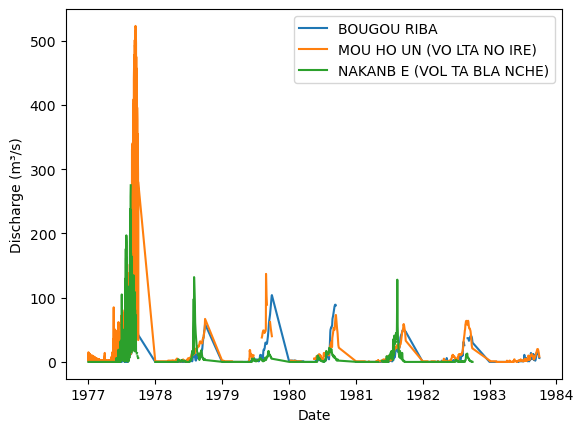

In [103]:
plt.plot(df_river1.index, df_river1["Discharge"], label=river_names[0])
plt.plot(df_river2.index, df_river2["Discharge"], label=river_names[1])
plt.plot(df_river3.index, df_river3["Discharge"], label=river_names[2])
plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.legend()
plt.show()

To analyse the water balance we also have to add the evaporation. To take into account evaporation we have to the daylight/sun hours per day. This data has to be found somewhere. 

In [104]:
## FROM IJSSELMEER CASE - THIS IS TO CALCULATE EVAPOTRANSPIRATION

def es_cal(T):
    es = 0.61 * np.exp((19.9 * T) / (273 + T))
    return es #kPa

def ea_cal(RH, T):
    ea = (RH / 100) * es_cal(T)
    return ea #kPa

def S_cal(T):
    S = (5430 * es_cal(T)) / (273 + T)**2
    return S #kPa/°C

def ra_cal(u):
    ra = (245 / (0.5 * u + 0.5)) 
    return ra #s/m

def EO(Rn, RH, T, u):
    rho = 1000 # density of water kg/m3
    rho_a = 1.205 # density of air kg/m3
    cp = 1004 # specific heat capacity of air J/(kg·K)
    gamma = 0.066 # psychrometric constant kPa/°C
    lam = 2.45e6 # latent heat of vaporization J/kg
    T = T
    es = es_cal(T)
    ea = ea_cal(RH, T)
    S = S_cal(T)
    ra = ra_cal(u)

    EO = (((S * Rn) / (rho * lam)) + ((cp * rho_a) / (rho * lam)) * ((es - ea) / ra)) / (S + gamma)
    return EO


Load the percipitation data and compare with the discharge data

In [105]:
filename = 'precipitation data volta\\mswep\\Black Volta_-2.75_9.55.csv'
blackvolta = pd.read_csv(filename, index_col=['time'], parse_dates=['time']) 
#Look what is in the file:
blackvolta.head(-15)

,precipitation
time,
1979-01-01,0.00
1979-01-02,0.00
1979-01-03,0.00
1979-01-04,0.00
1979-01-05,0.00
...,...
2017-10-12,12.33
2017-10-13,0.00
2017-10-14,0.06


Evaporation Data 

In [106]:
df_evap1 = pd.read_csv("ERA5_evaporation_BlackVolta_fixed/ERA5_evaporation_BlackVolta_fixed1.csv", index_col=0, parse_dates=True)

df_evap2 = pd.read_csv("ERA5_evaporation_BlackVolta_fixed/ERA5_evaporation_BlackVolta_fixed2.csv", index_col=0, parse_dates=True)

df_evap3 = pd.read_csv("ERA5_evaporation_BlackVolta_fixed/ERA5_evaporation_BlackVolta_fixed3.csv", index_col=0, parse_dates=True)

df_evap4 = pd.read_csv("ERA5_evaporation_BlackVolta_fixed/ERA5_evaporation_BlackVolta_fixed4.csv", index_col=0, parse_dates=True)

df_evap5 = pd.read_csv("ERA5_evaporation_BlackVolta_fixed/ERA5_evaporation_BlackVolta_fixed5.csv", index_col=0, parse_dates=True)

df_evap6 = pd.read_csv("ERA5_evaporation_BlackVolta_fixed/ERA5_evaporation_BlackVolta_fixed6.csv", index_col=0, parse_dates=True)

df_evap7 = pd.read_csv("ERA5_evaporation_BlackVolta_fixed/ERA5_evaporation_BlackVolta_fixed7.csv", index_col=0, parse_dates=True)

df_evap8 = pd.read_csv("ERA5_evaporation_BlackVolta_fixed/ERA5_evaporation_BlackVolta_fixed8.csv", index_col=0, parse_dates=True)


In [107]:
df_evap1.head()

,step,latitude,longitude,number,surface,valid_time,e
time,,,,,,,
1979-01-01,0 days 08:00:00,11.0,-3.0,0,0.0,1979-01-01 08:00:00,-0.000041
1979-01-01,0 days 08:00:00,11.0,-2.9,0,0.0,1979-01-01 08:00:00,-0.000037
1979-01-01,0 days 08:00:00,11.0,-2.8,0,0.0,1979-01-01 08:00:00,-0.000029
1979-01-01,0 days 08:00:00,11.0,-2.7,0,0.0,1979-01-01 08:00:00,-0.000030
1979-01-01,0 days 08:00:00,11.0,-2.6,0,0.0,1979-01-01 08:00:00,-0.000032


In [132]:
df_all = pd.concat(
    [df_evap1, df_evap2, df_evap3, df_evap4,
     df_evap5, df_evap6, df_evap7, df_evap8],
    ignore_index=True
)

df_all["valid_time"] = pd.to_datetime(df_all["valid_time"])

df_all["evap_mm"] = -df_all["e"] * 1000

df_evap_time = (
    df_all.groupby("valid_time")["evap_mm"]
          .mean()
          .to_frame()
          .sort_index()
)

print(df_evap_time.head(50))
print("\nSummary:")
print(df_evap_time.describe())

                      evap_mm
valid_time                   
1979-01-01 08:00:00  0.046565
1979-01-01 10:00:00  0.170901
1979-01-01 12:00:00  0.375900
1979-01-01 14:00:00  0.586200
1979-01-01 16:00:00  0.748099
1979-01-02 08:00:00  0.044686
1979-01-02 10:00:00  0.172857
1979-01-02 12:00:00  0.374006
1979-01-02 14:00:00  0.582264
1979-01-02 16:00:00  0.743460
1979-01-03 08:00:00  0.039440
1979-01-03 10:00:00  0.161993
1979-01-03 12:00:00  0.356075
1979-01-03 14:00:00  0.555638
1979-01-03 16:00:00  0.709543
1979-01-04 08:00:00  0.041757
1979-01-04 10:00:00  0.149405
1979-01-04 12:00:00  0.318073
1979-01-04 14:00:00  0.495531
1979-01-04 16:00:00  0.631317
1979-01-05 08:00:00  0.032528
1979-01-05 10:00:00  0.136685
1979-01-05 12:00:00  0.323900
1979-01-05 14:00:00  0.520960
1979-01-05 16:00:00  0.669703
1979-01-06 08:00:00  0.025856
1979-01-06 10:00:00  0.122460
1979-01-06 12:00:00  0.289756
1979-01-06 14:00:00  0.463446
1979-01-06 16:00:00  0.590525
1979-01-07 08:00:00  0.075074
1979-01-07

In [121]:
df_evap_daily = df_evap_time.resample("1D").sum() * 2


In [131]:
import os
import zipfile

# Save Excel
excel_evaporation = "evaporation_daily_design_year.xlsx"
df_evap_daily.to_excel(excel_evaporation, index=True)

# Zip it
zip_filename = "evaporation_daily_design_year.zip"
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(excel_evaporation)

print("Files created:")
print(" -", excel_evaporation)
print(" -", zip_filename)
print("Location:", os.getcwd())

Files created:
 - evaporation_daily_design_year.xlsx
 - evaporation_daily_design_year.zip
Location: c:\Users\ellis\Desktop\Environmental_Engineering\Steppingstone_WRE\Unit 3\Volta-Case


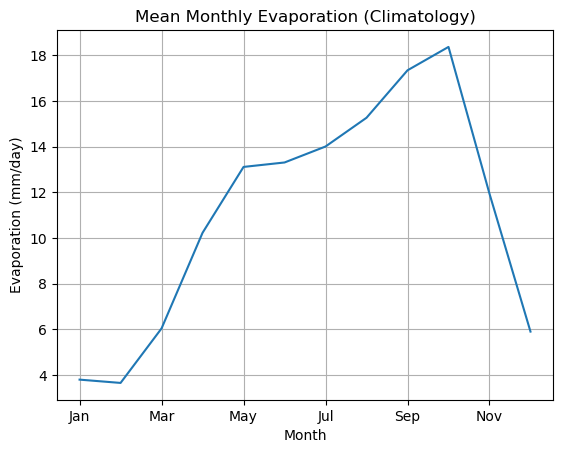


Monthly climatology (mm/day):
Jan     3.800805
Feb     3.656885
Mar     6.042264
Apr    10.225799
May    13.108949
Jun    13.303193
Jul    14.001970
Aug    15.260354
Sep    17.336522
Oct    18.359945
Nov    11.936413
Dec     5.902671
Name: evap_mm, dtype: float64

Seasonal means (mm/day):
season
DJF     4.477668
MAM     9.787626
JJA    14.198129
SON    15.904905
Name: evap_mm, dtype: float64


In [122]:

df_evap_daily.index = pd.to_datetime(df_evap_daily.index)

# ===============================
# 1. Monthly climatology (average seasonal cycle)
# ===============================
monthly_evap = (
    df_evap_daily
    .groupby(df_evap_daily.index.month)["evap_mm"]
    .mean()
)

# Replace month numbers with names
monthly_evap.index = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

# ===============================
# 2. Add month + season columns
# ===============================
df_evap_daily["month"] = df_evap_daily.index.month

def get_season(month):
    if month in [12,1,2]:
        return "DJF"
    elif month in [3,4,5]:
        return "MAM"
    elif month in [6,7,8]:
        return "JJA"
    else:
        return "SON"

df_evap_daily["season"] = df_evap_daily["month"].apply(get_season)

# ===============================
# 3. Seasonal averages
# ===============================
seasonal_means = (
    df_evap_daily
    .groupby("season")["evap_mm"]
    .mean()
    .reindex(["DJF","MAM","JJA","SON"])
)


plt.figure()
monthly_evap.plot()
plt.title("Mean Monthly Evaporation (Climatology)")
plt.ylabel("Evaporation (mm/day)")
plt.xlabel("Month")
plt.grid(True)
plt.show()

print("\nMonthly climatology (mm/day):")
print(monthly_evap)

print("\nSeasonal means (mm/day):")
print(seasonal_means)

Design of the reservoirs

In [ ]:
# #parameters to be defined:

# area = 1 * 10000 #m2 1 ha surface area of reservoir
# Cr = 0.5 #runoff coefficient
# Percip = 10 #mm/day changes per month
# k = 0.01 #seepage coefficient m/day
# E = 5 #mm/day evaporation changes per month
# Rriver = 100 #mm/day river inflow
# Dirr = 200 #direct abstraction (m3/day)
# Airr = 20*1000 #area of irrigation (m2)
# Acatch = 40*1000 #catchment area (m2)

In [ ]:
def volume(area):
    volume = 0.00857 * area**1.4367
    return volume

def Rcatch(Cr, Percip, Acatch):
    Rcatch = Cr * Percip * Acatch
    return Rcatch

def Pdir(Percip, area):
    Pdir = Percip * area
    return Pdir

def evap(E, area):
    evap = E * area
    return evap

def seep(k, area, L=3):
    seep = k * area * (volume(area) / area) / L
    return seep

def abstract(Dirr, Airr):
    abstract = Dirr * Airr
    return abstract

def delta_s(Rriver=Rriver, E=E, area=area, percip=Percip, Cr=Cr, Acatch=Acatch, k=k, Dirr=Dirr, Airr=Airr, L=3):
    delta_s = (Rcatch(Cr, percip, Acatch) + Rriver + Pdir(percip, area)) - evap(E, area) - seep(area, k) - abstract(Dirr, Airr)
    return delta_s

For now a trial:


only the blackvolta percipitation data and black volta river discharge averaged to create a single design year. The aim will be to create the smallest reservoir that fullfills the irrigation needs for a specific area

Monthly design year precipitation (mm/day):
     precipitation
Jan       0.083251
Feb       0.317719
Mar       0.949768
Apr       2.488590
May       3.667395
Jun       3.886889
Jul       4.684202
Aug       5.669132
Sep       5.606342
Oct       2.530265
Nov       0.329482
Dec       0.066188


C:\Users\ellis\AppData\Local\Temp\ipykernel_33052\1298024135.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  precip_monthly = blackvolta.resample("M").mean()


<Figure size 640x480 with 0 Axes>

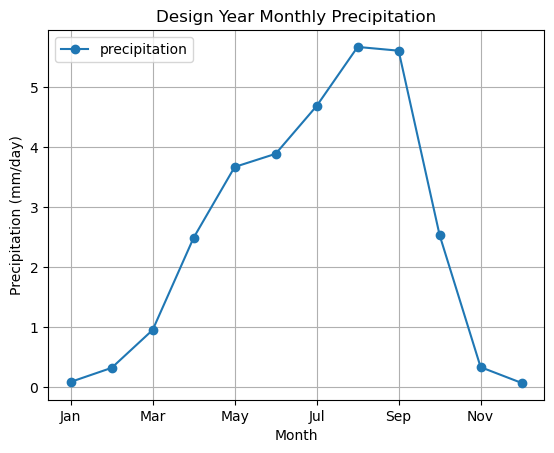

In [125]:
blackvolta.index = pd.to_datetime(blackvolta.index)

# If daily data → first aggregate to monthly totals (mm/month)
precip_monthly = blackvolta.resample("M").mean()

# Now compute climatological monthly average (design year)
precip_design_year = (
    precip_monthly
    .groupby(precip_monthly.index.month)
    .mean()
)

# Replace month numbers with names
precip_design_year.index = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

print("Monthly design year precipitation (mm/day):")
print(precip_design_year)

# Plot
plt.figure()
precip_design_year.plot(marker='o')
plt.title("Design Year Monthly Precipitation")
plt.ylabel("Precipitation (mm/day)")
plt.xlabel("Month")
plt.grid(True)
plt.show()

C:\Users\ellis\AppData\Local\Temp\ipykernel_33052\703791467.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  river_monthly = river_series.resample("M").mean()


Jan     1.835418
Feb     1.129750
Mar     0.655914
Apr     0.872222
May     3.555743
Jun     7.114024
Jul    12.429724
Aug    37.325594
Sep    69.278912
Oct     0.000000
Nov     0.000000
Dec     0.000000
Name: Discharge, dtype: float64


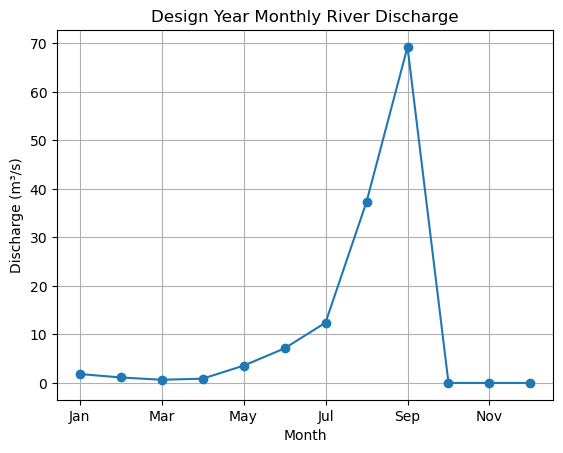

Monthly design year river flow (mm/month):
Jan     1.835418
Feb     1.129750
Mar     0.655914
Apr     0.872222
May     3.555743
Jun     7.114024
Jul    12.429724
Aug    37.325594
Sep    69.278912
Oct     0.000000
Nov     0.000000
Dec     0.000000
Name: Discharge, dtype: float64


In [126]:
df_river2.index = pd.to_datetime(df_river2.index)
river_series = pd.to_numeric(df_river2["Discharge"], errors="coerce")
river_monthly = river_series.resample("M").mean()

river_design_year = (
    river_monthly
    .groupby(river_monthly.index.month)
    .mean()
    .reindex(range(1,13))      # ensures all months exist
    .fillna(0)                 # replace missing with 0
)

river_design_year.index = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

print(river_design_year)

plt.figure()
river_design_year.plot(marker="o")
plt.title("Design Year Monthly River Discharge")
plt.ylabel("Discharge (m³/s)")
plt.xlabel("Month")
plt.grid(True)
plt.show()


print("Monthly design year river flow (mm/month):")
print(river_design_year)

In [127]:
area = np.linspace(10000, 40*10000, num = 10)
Cr = 0.31 #runoff coefficient
Percip = precip_design_year #mm/day changes per month
k = 0.01 #seepage coefficient m/day
E = monthly_evap #mm/day evaporation changes per month
Rriver = river_design_year #m3/s
Dirr = 5 #depth of irrigation necessary (mm/day)
Airr = 20*1000 #area of irrigation (m2)
Acatch = 40*1000 #catchment area (m2)

In [128]:

SEC_PER_DAY = 86400.0

def mmday_to_mday(x_mm_day):
    return x_mm_day / 1000.0

def m3s_to_m3day(q_m3s):
    return q_m3s * SEC_PER_DAY

def runoff_catchment_m3day(Cr, P_m_day, Acatch_m2):
    return Cr * P_m_day * Acatch_m2

def pdir_m3day(P_m_day, Ares_m2):
    return P_m_day * Ares_m2

def evap_m3day(E_m_day, Ares_m2):
    return E_m_day * Ares_m2

def seep_m3day(k_m_day, Ares_m2):
    return k_m_day * Ares_m2

def irrigation_m3day(Dirr_m_day, Airr_m2):
    return Dirr_m_day * Airr_m2

def delta_s_m3day(Qriver_in_m3day, P_m_day, E_m_day, Ares_m2, Cr, Acatch_m2, k_m_day, Dirr_m_day, Airr_m2):
    inflow  = runoff_catchment_m3day(Cr, P_m_day, Acatch_m2) + Qriver_in_m3day + pdir_m3day(P_m_day, Ares_m2)
    outflow = evap_m3day(E_m_day, Ares_m2) + seep_m3day(k_m_day, Ares_m2) + irrigation_m3day(Dirr_m_day, Airr_m2)
    return inflow - outflow  # m3/day

def make_design_year_daily(monthly_series, year=2001):
    """
    monthly_series: pandas Series or 1-col DataFrame with 12 values.
                   Index can be 1..12 or Jan..Dec.
    Returns: daily Series (one year) with month-wise constant values.
    """
    if isinstance(monthly_series, pd.DataFrame):
        # take first column
        monthly_series = monthly_series.iloc[:, 0]

    s = monthly_series.copy()

    # Map month names to numbers if needed
    if s.index.dtype == object:
        name_to_num = {"Jan":1,"Feb":2,"Mar":3,"Apr":4,"May":5,"Jun":6,"Jul":7,"Aug":8,"Sep":9,"Oct":10,"Nov":11,"Dec":12}
        s.index = [name_to_num[i] for i in s.index]
        s = s.sort_index()

    idx = pd.date_range(f"{year}-01-01", f"{year}-12-31", freq="D")
    out = pd.Series(index=idx, dtype=float)
    for m in range(1, 13):
        out[out.index.month == m] = float(s.loc[m])
    return out




In [130]:
areas_ha = np.linspace(1, 40, 10)

rows = []
for A_ha in areas_ha:
    Ares_m2 = A_ha * 10_000.0

    S = 100.0      # starting storage (m3)
    Smax = 0.0   # required capacity (max storage reached)
    failed = False

    for t in P_m_day.index:
        dS = delta_s_m3day(
            Qriver_in_m3day=float(Qin_m3day.loc[t]),
            P_m_day=float(P_m_day.loc[t]),
            E_m_day=float(E_m_day.loc[t]),
            Ares_m2=Ares_m2,
            Cr=Cr,
            Acatch_m2= Acatch,
            k_m_day = k,
            Dirr_m_day=Dirr,
            Airr_m2=Airr
        )

        S_new = S + dS

        if S_new < 0:
            failed = True
            break

        S = S_new
        if S > Smax:
            Smax = S

    rows.append({"area_ha": A_ha, "feasible": not failed, "required_capacity_m3": Smax})

df_sizing = pd.DataFrame(rows)
print(df_sizing)

feasible = df_sizing[df_sizing["feasible"]].sort_values("area_ha")
if feasible.empty:
    print("\nNo feasible reservoir area found between 1 and 40 ha for these inputs.")
else:
    best = feasible.iloc[0]
    print("\nSmallest feasible reservoir surface area (ha) and required capacity (m3):")
    print(best)


     area_ha  feasible  required_capacity_m3
0   1.000000     False                   0.0
1   5.333333     False                   0.0
2   9.666667     False                   0.0
3  14.000000     False                   0.0
4  18.333333     False                   0.0
5  22.666667     False                   0.0
6  27.000000     False                   0.0
7  31.333333     False                   0.0
8  35.666667     False                   0.0
9  40.000000     False                   0.0

No feasible reservoir area found between 1 and 40 ha for these inputs.


In [135]:
crop_data = pd.read_excel("cropdata.xlsx")
print(crop_data.head())

  Unnamed: 0  Kc_intitial  Kc_mid  Kc_end  Lc_intitial (days)  \
0    Cassava         0.30    0.80    0.30                20.0   
1       Rice         1.05    1.20    0.90                30.0   
2      Maize          NaN    1.15    1.05                20.0   
3        Yam          NaN    0.95    0.95                 NaN   

   Lc_develop (days)  Lc_mid (days)  Lc_end (days)  Lc_total (days)  \
0               40.0           90.0           60.0              210   
1               30.0           60.0           30.0              150   
2               25.0           25.0           10.0               80   
3                NaN            NaN            NaN              300   

  start month  
0    November  
1        June  
2        June  
3    December  


In [162]:
cd = crop_data.copy()
cd.columns = cd.columns.str.strip()

if "crop" not in cd.columns:
    if "Unnamed: 0" in cd.columns:
        cd = cd.rename(columns={"Unnamed: 0": "crop"})
    else:
        cd = cd.rename(columns={cd.columns[0]: "crop"})

cd["crop"] = cd["crop"].astype(str).str.strip()

rename_map = {
    # fix typos here if your file has them
    "Kc end": "Kc_end",
    "Lc_initial (days)": "Lc_initial_days",
    "Lc_develop (days)": "Lc_develop_days",
    "Lc_mid (days)": "Lc_mid_days",
    "Lc_end (days)": "Lc_end_days",
    "start month": "start_month",
    "Kc_intitial": "Kc_initial",           # your earlier typo
    "Lc_intitial (days)": "Lc_initial_days" # your earlier typo
}
cd = cd.rename(columns={k: v for k, v in rename_map.items() if k in cd.columns})

month_map = {m: i for i, m in enumerate(
    ["January","February","March","April","May","June","July","August","September","October","November","December"], start=1
)}
cd["start_month_num"] = cd["start_month"].map(month_map)
# ---------- 2) Create an MM-DD index (365 days, no leap day) ----------
base = pd.date_range("2001-01-01", "2001-12-31", freq="D")  # 2001 is non-leap
md_index = base.strftime("%m-%d")  # strings like '01-01' ... '12-31'

# ---------- 3) Build daily Kc curve on MM-DD index ----------
def kc_design_md_for_crop(row, kc_offseason=0.0):
    # Start with offseason everywhere
    kc = pd.Series(kc_offseason, index=md_index, dtype=float)

    kc_ini = float(row["Kc_initial"])
    kc_mid = float(row["Kc_mid"])
    kc_end = float(row["Kc_end"])

    L_ini = int(row["Lc_initial_days"]) if pd.notna(row["Lc_initial_days"]) else 0
    L_dev = int(row["Lc_develop_days"]) if pd.notna(row["Lc_develop_days"]) else 0
    L_mid = int(row["Lc_mid_days"]) if pd.notna(row["Lc_mid_days"]) else 0
    L_end = int(row["Lc_end_days"]) if pd.notna(row["Lc_end_days"]) else 0

    season_len = L_ini + L_dev + L_mid + L_end
    if season_len <= 0:
        return kc

    start_month = int(row["start_month_num"])
    start_date = pd.Timestamp(year=2001, month=start_month, day=1)

    # Create the season dates in the base non-leap year, and wrap if needed
    season_dates = pd.date_range(start_date, periods=season_len, freq="D")

    part1 = np.full(L_ini, kc_ini)
    part2 = np.linspace(kc_ini, kc_mid, num=L_dev, endpoint=False) if L_dev > 0 else np.array([])
    part3 = np.full(L_mid, kc_mid)
    part4 = np.linspace(kc_mid, kc_end, num=L_end, endpoint=True) if L_end > 0 else np.array([])
    kc_vals = np.concatenate([part1, part2, part3, part4])

    for d, v in zip(season_dates, kc_vals):
        # wrap to within 2001
        wrapped = base[(d - base[0]).days % len(base)]
        kc[wrapped.strftime("%m-%d")] = float(v)

    return kc

kc_by_crop = {row["crop"]: kc_design_md_for_crop(row, kc_offseason=0.0) for _, row in cd.iterrows()}
kc_df_md = pd.DataFrame(kc_by_crop)  # 365 rows, index='MM-DD'

# ---------- 4) Combine to one overall Kc ----------
weights = {c: 1.0 for c in kc_df_md.columns}  # replace with area fractions if you have them
w = pd.Series(weights, dtype=float)
w = w / w.sum()

kc_combined_md = (kc_df_md[w.index] * w).sum(axis=1)
kc_combined_md.name = "Kc_combined"

print(kc_combined_md.head(10)) #coefficients for each day of the year
print("\nLength:", len(kc_combined_md)) 

01-01    0.2
01-02    0.2
01-03    0.2
01-04    0.2
01-05    0.2
01-06    0.2
01-07    0.2
01-08    0.2
01-09    0.2
01-10    0.2
Name: Kc_combined, dtype: float64

Length: 365


In [141]:
percipitation_area = pd.read_csv("area_precipitation_volta.csv", index_col=1)
percipitation_area.head(10)
df_Acatch = percipitation_area["area_km2"]
print(df_Acatch)

station
Black_volta    94515.333828
Lake_volta     34082.047808
Mouhoun        61848.799530
Nakambe        72625.985186
Oti            72933.545722
Pendjari       74986.245606
Name: area_km2, dtype: float64


In [161]:
### LOADING IN THE DATAFRAMES TO BE USED IN THE CALCULATIONS

df_evap_daily = df_evap_daily.copy()
df_evap_daily.index = pd.to_datetime(df_evap_daily.index)

# Build month-day key and remove Feb 29
md = df_evap_daily.index.strftime("%m-%d")
mask = md != "02-29"

evap_design_year_daily = (
    df_evap_daily.loc[mask]
    .groupby(df_evap_daily.loc[mask].index.strftime("%m-%d"))["evap_mm"]
    .mean()
    .sort_index()
)

print(evap_design_year_daily.head())
print("Length:", len(evap_design_year_daily)) ##mm/day


valid_time
01-01    4.545005
01-02    4.453657
01-03    4.387762
01-04    4.291726
01-05    4.128277
Name: evap_mm, dtype: float64
Length: 365


In [168]:
filenames = [
    r'precipitation data volta\mswep\Black Volta_-2.75_9.55.csv',
    r'precipitation data volta\mswep\Lake Volta_0.05_6.45.csv',
    r'precipitation data volta\mswep\Mouhoun_-3.95_12.05.csv',
    r'precipitation data volta\mswep\Nakambe_-2.15_13.55.csv',
    r'precipitation data volta\mswep\Oti_0.15_8.45.csv',
    r'precipitation data volta\mswep\Pendjari_1.15_11.15.csv'
]
blackvolta = pd.read_csv(filenames[0], index_col=['time'], parse_dates=['time'])
lakevolta = pd.read_csv(filenames[1], index_col=['time'], parse_dates=['time'])
mouhoun = pd.read_csv(filenames[2], index_col=['time'], parse_dates=['time'])
nakambe = pd.read_csv(filenames[3], index_col=['time'], parse_dates=['time'])
oti = pd.read_csv(filenames[4], index_col=['time'], parse_dates=['time'])
pendjari = pd.read_csv(filenames[5], index_col=['time'], parse_dates=['time']) 
#Look what is in the file:


blackvolta.index = pd.to_datetime(blackvolta.index)
lakevolta.index = pd.to_datetime(lakevolta.index)
mouhoun.index = pd.to_datetime(mouhoun.index)
nakambe.index = pd.to_datetime(nakambe.index)
oti.index = pd.to_datetime(oti.index)
pendjari.index = pd.to_datetime(pendjari.index)

def daily_design_year(df, value_col=None, drop_feb29=True):
    """
    df: dataframe with DatetimeIndex
    value_col: column to use (defaults to first column)
    Returns: Series indexed by 'MM-DD' with 365 values
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)

    # choose the variable column
    if value_col is None:
        value_col = df.columns[0]

    md = df.index.strftime("%m-%d")
    if drop_feb29:
        mask = md != "02-29"
        df = df.loc[mask]
        md = df.index.strftime("%m-%d")

    out = df.groupby(md)[value_col].mean().sort_index()
    return out

# Put your basin dataframes in a dict
basins = {
    "blackvolta": blackvolta,
    "lakevolta": lakevolta,
    "mouhoun": mouhoun,
    "nakambe": nakambe,
    "oti": oti,
    "pendjari": pendjari,
}

# Create 365-day design year series for each basin
design_year_by_basin = {name: daily_design_year(df) for name, df in basins.items()}

# Example: inspect one
print(design_year_by_basin["blackvolta"].head())
print("Length:", len(design_year_by_basin["blackvolta"]))

time
01-01    0.001026
01-02    0.069231
01-03    0.029487
01-04    0.081282
01-05    0.000000
Name: precipitation, dtype: float64
Length: 365


In [ ]:

# Dict (MM-DD index) -> DataFrame with one column per basin
df_percip_design = pd.DataFrame(design_year_by_basin)

# Convert mm/day -> m/day
df_percip_design = df_percip_design * 1e-3

print(df_percip_design.head())
print("Shape:", df_percip_design.shape)

       blackvolta  lakevolta   mouhoun  nakambe       oti  pendjari
time                                                               
01-01    0.000001   0.000380  0.000000      0.0  0.000000  0.000000
01-02    0.000069   0.000067  0.000005      0.0  0.000279  0.000000
01-03    0.000029   0.000011  0.000000      0.0  0.000027  0.000001
01-04    0.000081   0.000163  0.000000      0.0  0.000000  0.000000
01-05    0.000000   0.000114  0.000000      0.0  0.000008  0.000005
Shape: (365, 6)


In [183]:
evap_design = evap_design_year_daily.copy() * 1e-3 ## m/day
kc_combined_md ##dimensionless crop coefficients
df_Acatch = df_Acatch.copy() * 1e6 ## catchment area in m2
df_percip_design  ## df of 365-day design year precipitation series for each basin (m/day)

area = np.linspace(10000, 40*10000, num = 10)
Cr = 0.31 #runoff coefficient
k = 10e-5 #seepage coefficient m/day
Rriver = river_design_year #m3/s
Airr = 0.2 * df_Acatch #area of irrigation (m2), here assumed to be 80% of catchment area



In [184]:
print(f'river_design_year.head() looks like {river_design_year.head()}')
print(f'df_Acatch.index() looks like {df_Acatch.index}')

river_design_year.head() looks like Jan    1.835418
Feb    1.129750
Mar    0.655914
Apr    0.872222
May    3.555743
Name: Discharge, dtype: float64
df_Acatch.index() looks like Index(['Black_volta', 'Lake_volta', 'Mouhoun', 'Nakambe', 'Oti', 'Pendjari'], dtype='object', name='station')


In [190]:
import numpy as np
import pandas as pd

SEC_PER_DAY = 86400.0

# -----------------------------
# 1) STANDARDIZE basin names
# -----------------------------
# Your official basin names (from df_Acatch.index)
official_basins = list(df_Acatch.index)

# Your precipitation columns currently look like:
# ['blackvolta','lakevolta','mouhoun','nakambe','oti','pendjari']
# Map them to official names:
name_map = {
    "blackvolta": "Black_volta",
    "lakevolta": "Lake_volta",
    "mouhoun": "Mouhoun",
    "nakambe": "Nakambe",
    "oti": "Oti",
    "pendjari": "Pendjari",
}

# Rename precip columns
df_percip_design2 = df_percip_design.rename(columns=name_map).copy()

# Keep only basins that exist in df_Acatch
df_percip_design2 = df_percip_design2[[b for b in df_percip_design2.columns if b in official_basins]]

# Put precip on a 2001 daily index
df_percip_design2.index = pd.date_range("2001-01-01", "2001-12-31", freq="D")

# Put evap and Kc on same 2001 index (they currently have MM-DD index)
E_design = evap_design.copy()
E_design.index = pd.date_range("2001-01-01", "2001-12-31", freq="D")

Kc_design = kc_combined_md.copy()
Kc_design.index = pd.date_range("2001-01-01", "2001-12-31", freq="D")

# River monthly design (m3/s) -> daily 2001 (month-constant)
def monthly_to_daily_design(monthly_series, year=2001):
    s = monthly_series.copy()
    if s.index.dtype == object:
        name_to_num = {"Jan":1,"Feb":2,"Mar":3,"Apr":4,"May":5,"Jun":6,"Jul":7,"Aug":8,"Sep":9,"Oct":10,"Nov":11,"Dec":12}
        s.index = [name_to_num[str(i)[:3]] for i in s.index]
        s = s.sort_index()
    idx = pd.date_range(f"{year}-01-01", f"{year}-12-31", freq="D")
    out = pd.Series(index=idx, dtype=float)
    for m in range(1, 13):
        out[out.index.month == m] = float(s.loc[m])
    return out

Qriver_design = monthly_to_daily_design(river_design_year, year=2001)  # m3/s

# Convert df_Acatch km2 -> m2 if you haven't already (you said you did, but ensure)
# df_Acatch_m2 = df_Acatch * 1e6  # if df_Acatch is still in km2
df_Acatch_m2 = df_Acatch.copy()   # if you already converted earlier

# -----------------------------
# 2) Model functions (unit-consistent)
# -----------------------------
def capacity_m3_from_area_ha(area_ha):
    # assuming: area [ha] -> volume [million m3]
    return (0.00857 * (area_ha ** 1.4367)) * 1e6

def Rcatch(Cr, P_m_day, Acatch_m2):
    return Cr * P_m_day * Acatch_m2

def Pdir(P_m_day, Ares_m2):
    return P_m_day * Ares_m2

def evap_loss(E_m_day, Ares_m2):
    return E_m_day * Ares_m2

def seep_loss(k_m_day, Ares_m2, storage_m3, L=3.0):
    h = storage_m3 / Ares_m2 if Ares_m2 > 0 else 0.0
    return k_m_day * Ares_m2 * (h / L)

def abstract(Dirr_m_day, Airr_m2):
    return Dirr_m_day * Airr_m2

def make_Dirr(P_m_day, ET0_m_day, Kc, eff_rain=0.8):
    # Dirr in m/day
    return (Kc * ET0_m_day - eff_rain * P_m_day).clip(lower=0.0)

def simulate_basin(P_m_day, E_m_day, Kc, Qriver_m3s, Acatch_m2, Airr_m2,
                   area_ha, Cr, k_m_day, frac_river=0.20, eff_rain=0.8, L=3.0):
    idx = P_m_day.index
    Ares_m2 = area_ha * 10_000.0
    cap_m3 = capacity_m3_from_area_ha(area_ha)

    Qin_m3day = frac_river * (Qriver_m3s * SEC_PER_DAY)  # m3/day
    Dirr_m_day = make_Dirr(P_m_day, E_m_day, Kc, eff_rain=eff_rain)

    S = 0.0
    Smax = 0.0

    for t in idx:
        inflow = (
            Rcatch(Cr, float(P_m_day.loc[t]), float(Acatch_m2))
            + float(Qin_m3day.loc[t])
            + Pdir(float(P_m_day.loc[t]), Ares_m2)
        )
        outflow = (
            evap_loss(float(E_m_day.loc[t]), Ares_m2)
            + seep_loss(k_m_day, Ares_m2, S, L=L)
            + abstract(float(Dirr_m_day.loc[t]), float(Airr_m2))
        )

        S = S + (inflow - outflow)

        if S < 0:
            return False, np.nan, cap_m3

        if S > cap_m3:
            S = cap_m3

        Smax = max(Smax, S)

    return True, Smax, cap_m3

# -----------------------------
# 3) Run sizing for all basins
# -----------------------------
areas_ha = np.linspace(1, 40, 10)
rows = []

for basin in df_percip_design2.columns:
    Acatch_m2 = float(df_Acatch_m2.loc[basin])
    Airr_m2 = 1000*10000

    P_basin = df_percip_design2[basin]  # m/day
    best_area = None

    for A_ha in areas_ha:
        feasible, Smax, cap = simulate_basin(
            P_m_day=P_basin,
            E_m_day=E_design,
            Kc=Kc_design,
            Qriver_m3s=Qriver_design,
            Acatch_m2=Acatch_m2,
            Airr_m2=Airr_m2,
            area_ha=float(A_ha),
            Cr=Cr,
            k_m_day=k,
            frac_river=0.20,
            eff_rain=0.8,
            L=3.0
        )

        rows.append({
            "basin": basin,
            "area_ha": float(A_ha),
            "feasible": feasible,
            "max_storage_used_m3": Smax,
            "capacity_m3": cap
        })

        if feasible and best_area is None:
            best_area = float(A_ha)

    if best_area is None:
        print(f"{basin}: no feasible area found in 1–40 ha")
    else:
        print(f"{basin}: smallest feasible area = {best_area:.2f} ha")

df_results = pd.DataFrame(rows)

# Summary safely (won't crash if none feasible)
if df_results.empty or ("feasible" not in df_results.columns) or df_results[df_results["feasible"]].empty:
    summary = pd.DataFrame()
    print("\nNo feasible solutions found for any basin (check inputs/assumptions).")
else:
    summary = (df_results[df_results["feasible"]]
               .sort_values(["basin","area_ha"])
               .groupby("basin")
               .first()[["area_ha","capacity_m3","max_storage_used_m3"]])
    print("\n=== Smallest feasible reservoir per basin ===")
    print(summary)

df_results, summary

Black_volta: smallest feasible area = 5.33 ha
Lake_volta: smallest feasible area = 1.00 ha
Mouhoun: smallest feasible area = 5.33 ha
Nakambe: smallest feasible area = 18.33 ha
Oti: smallest feasible area = 1.00 ha
Pendjari: smallest feasible area = 5.33 ha

=== Smallest feasible reservoir per basin ===
               area_ha    capacity_m3  max_storage_used_m3
basin                                                     
Black_volta   5.333333   94942.331907         94942.331907
Lake_volta    1.000000    8570.000000          8570.000000
Mouhoun       5.333333   94942.331907         94942.331907
Nakambe      18.333333  559602.687157        559602.687157
Oti           1.000000    8570.000000          8570.000000
Pendjari      5.333333   94942.331907         94942.331907


(          basin    area_ha  feasible  max_storage_used_m3   capacity_m3
 0   Black_volta   1.000000     False                  NaN  8.570000e+03
 1   Black_volta   5.333333      True         9.494233e+04  9.494233e+04
 2   Black_volta   9.666667      True         2.231146e+05  2.231146e+05
 3   Black_volta  14.000000      True         3.798595e+05  3.798595e+05
 4   Black_volta  18.333333      True         5.596027e+05  5.596027e+05
 5   Black_volta  22.666667      True         7.590428e+05  7.590428e+05
 6   Black_volta  27.000000      True         9.759356e+05  9.759356e+05
 7   Black_volta  31.333333      True         1.208630e+06  1.208630e+06
 8   Black_volta  35.666667      True         1.455849e+06  1.455849e+06
 9   Black_volta  40.000000      True         1.716566e+06  1.716566e+06
 10   Lake_volta   1.000000      True         8.570000e+03  8.570000e+03
 11   Lake_volta   5.333333      True         9.494233e+04  9.494233e+04
 12   Lake_volta   9.666667      True         2.231

In [191]:
###################### DESIGN PLOTS ###################

In [192]:

basin = "Black_volta"  # change for other basins

df_design = pd.DataFrame({
    "P_mm_day": df_percip_design2[basin] * 1000,    # m/day -> mm/day
    "E_mm_day": E_design * 1000,                    # m/day -> mm/day
    "Kc": Kc_design,
    "Q_m3s": Qriver_design
})

df_design.index.name = "date"
df_design.head()

,P_mm_day,E_mm_day,Kc,Q_m3s
date,,,,
2001-01-01,0.001026,4.545005,0.2,1.835418
2001-01-02,0.069231,4.453657,0.2,1.835418
2001-01-03,0.029487,4.387762,0.2,1.835418
2001-01-04,0.081282,4.291726,0.2,1.835418
2001-01-05,0.000000,4.128277,0.2,1.835418


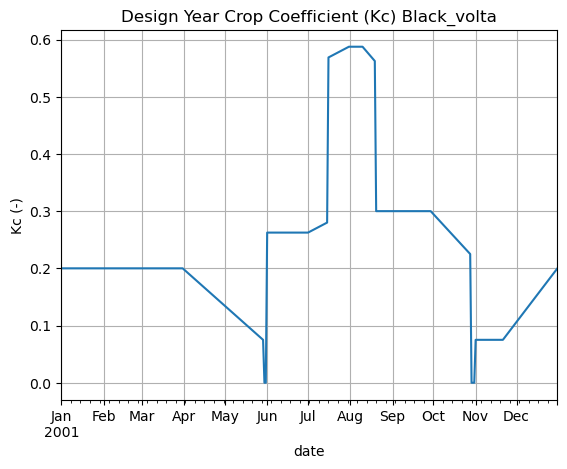

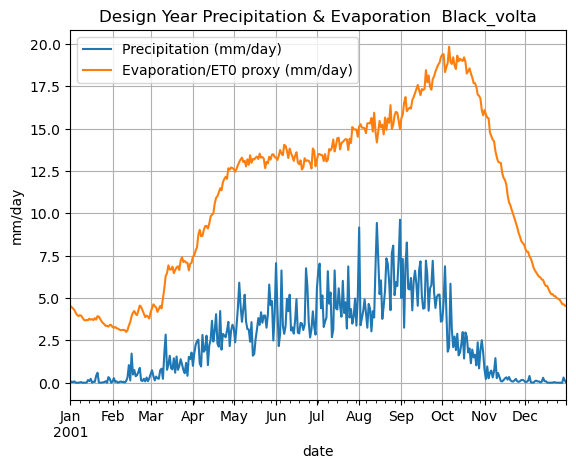

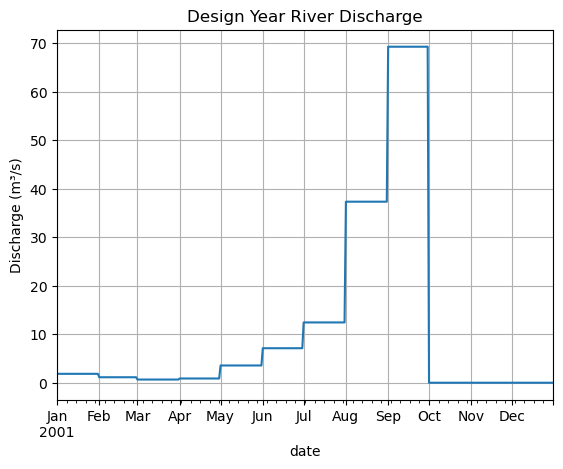

<Figure size 640x480 with 0 Axes>

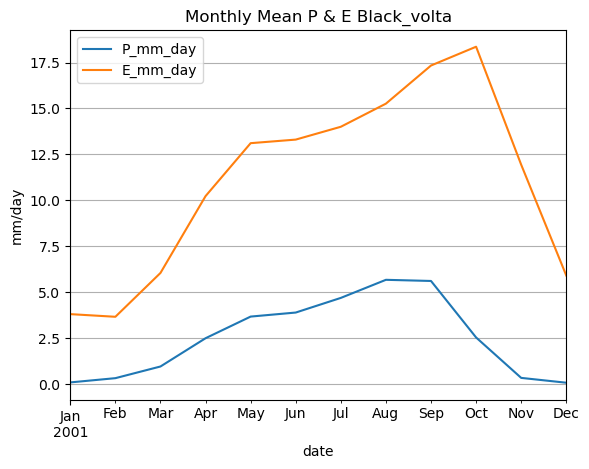

In [195]:

# 1) Crop coefficient Kc
plt.figure()
df_design["Kc"].plot()
plt.title(f"Design Year Crop Coefficient (Kc) {basin}")
plt.ylabel("Kc (-)")
plt.grid(True)
plt.show()

# 2) Precipitation + Evaporation
plt.figure()
df_design["P_mm_day"].plot(label="Precipitation (mm/day)")
df_design["E_mm_day"].plot(label="Evaporation/ET0 proxy (mm/day)")
plt.title(f"Design Year Precipitation & Evaporation  {basin}")
plt.ylabel("mm/day")
plt.legend()
plt.grid(True)
plt.show()

# 3) River discharge
plt.figure()
df_design["Q_m3s"].plot()
plt.title("Design Year River Discharge")
plt.ylabel("Discharge (m³/s)")
plt.grid(True)
plt.show()

# 4) Monthly averages (nice for seasonal story)
monthly = df_design.resample("ME").mean(numeric_only=True)
plt.figure()
monthly[["P_mm_day","E_mm_day"]].plot()
plt.title(f"Monthly Mean P & E {basin}")
plt.ylabel("mm/day")
plt.grid(True)
plt.show()

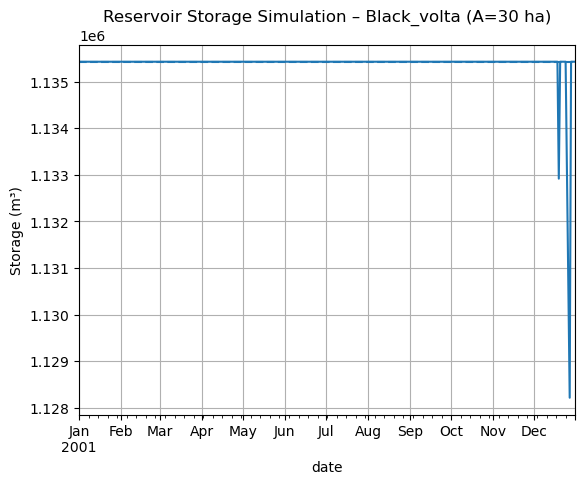

In [206]:
import numpy as np

SEC_PER_DAY = 86400.0

def capacity_m3_from_area_ha(area_ha):
    return (0.00857 * (area_ha ** 1.4367)) * 1e6

def simulate_storage_series(basin, area_ha, Cr, k_m_day, frac_river=0.10, eff_rain=0.8, L=3.0, command_area_factor=3.0):
    P = df_percip_design2[basin]         # m/day
    E = E_design                         # m/day
    Kc = Kc_design                        # -
    Q = Qriver_design                     # m3/s
    Acatch_m2 = float(df_Acatch_m2.loc[basin])

    Ares_m2 = area_ha * 10_000
    cap_m3 = capacity_m3_from_area_ha(area_ha)

    Airr_m2 = 1000000
    Qin_m3day = frac_river * (Q * SEC_PER_DAY)

    Dirr = (Kc*E - eff_rain*P).clip(lower=0.0)   # m/day

    S = 0.0
    S_series = pd.Series(index=P.index, dtype=float)

    for t in P.index:
        inflow = (Cr*P.loc[t]*Acatch_m2) + Qin_m3day.loc[t] + (P.loc[t]*Ares_m2)
        h = S / Ares_m2
        seep = k_m_day * Ares_m2 * (h / L)
        outflow = (E.loc[t]*Ares_m2) + seep + (Dirr.loc[t]*Airr_m2)

        S = S + (inflow - outflow)
        S = min(max(S, 0), cap_m3)  # clip 0..capacity for plotting

        S_series.loc[t] = S

    return S_series, cap_m3

# Example plot
basin = "Black_volta"
Ares_ha = 30

S_series, cap_m3 = simulate_storage_series(basin, Ares_ha, Cr=Cr, k_m_day=k, command_area_factor=3.0)

plt.figure()
S_series.plot()
plt.axhline(cap_m3, linestyle="--")
plt.title(f"Reservoir Storage Simulation – {basin} (A={Ares_ha} ha)")
plt.ylabel("Storage (m³)")
plt.grid(True)
plt.show()

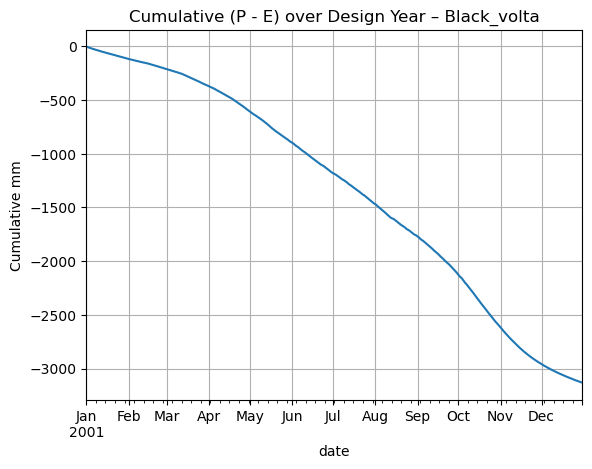

In [207]:
net_mm_day = df_design["P_mm_day"] - df_design["E_mm_day"]
cum = net_mm_day.cumsum()

plt.figure()
cum.plot()
plt.title(f"Cumulative (P - E) over Design Year – {basin}")
plt.ylabel("Cumulative mm")
plt.grid(True)
plt.show()

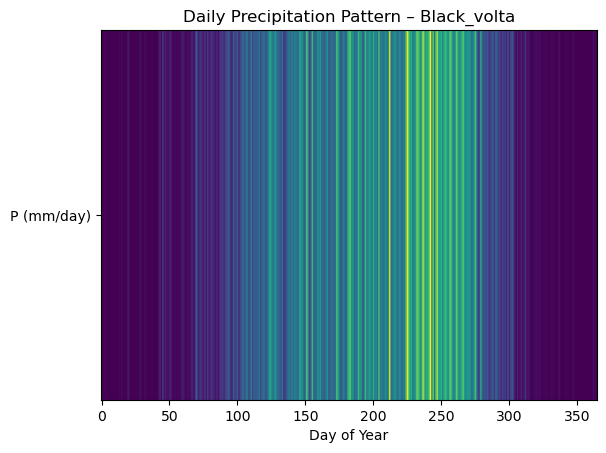

In [208]:
import numpy as np

# convert to day-of-year x variable heatmap (here: precipitation)
doy = df_design.index.dayofyear
heat = pd.DataFrame({"doy": doy, "P": df_design["P_mm_day"].values}).set_index("doy")

plt.figure()
plt.imshow(heat.T, aspect="auto")
plt.title(f"Daily Precipitation Pattern – {basin}")
plt.yticks([0], ["P (mm/day)"])
plt.xlabel("Day of Year")
plt.show()

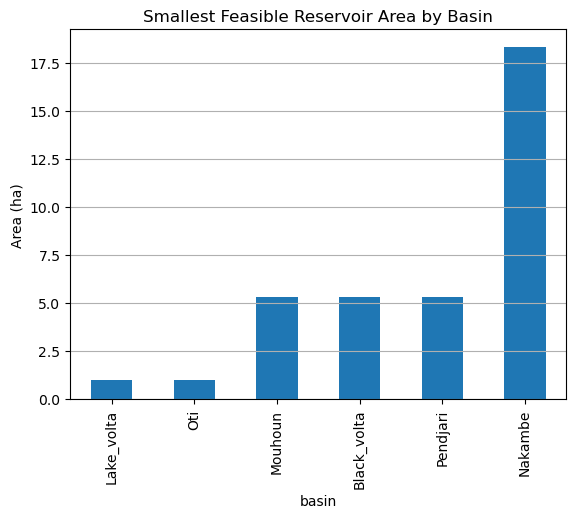

In [210]:
plt.figure()
summary["area_ha"].sort_values().plot(kind="bar")
plt.title("Smallest Feasible Reservoir Area by Basin")
plt.ylabel("Area (ha)")
plt.grid(True, axis="y")
plt.show()